Cloning into 'GreenPulse'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 166 (delta 8), reused 5 (delta 5), pack-reused 153 (from 3)
Receiving objects: 100% (166/166), 193.13 MiB | 2.19 MiB/s, done.
Resolving deltas: 100% (54/54), done.
Updating files: 100% (49/49), done.
/content/GreenPulse
Cloning into 'GreenPulse'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 166 (delta 8), reused 5 (delta 5), pack-reused 153 (from 3)
Receiving objects: 100% (166/166), 193.13 MiB | 5.49 MiB/s, done.
Resolving deltas: 100% (54/54), done.
Updating files: 100% (49/49), done.
/content/GreenPulse/GreenPulse
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


100%|██████████| 534M/534M [00:26<00:00, 20.8MB/s]

Extracting files...


/kaggle/input/plantvillage-dataset
/root/.cache/kagglehub/datasets/karagwaanntreasure/plant-disease-detection/versions/1
Class mapping defined for 7 unified target classes
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


100%|██████████| 1.01G/1.01G [00:50<00:00, 21.8MB/s]

Extracting files...


Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ Tomato_Early_Blight: 1000 unique images
  └─ Maize_Northern_Leaf_Blight: 2116 unique images
  └─ Cocoa_Black_Pod_Rot: 943 unique images
  └─ Maize_Healthy: 2084 unique images
  └─ Cocoa_Pod_Borer: 103 unique images
  └─ Cocoa_Healthy: 3344 unique images
  └─ Maize_Common_Rust: 2144 unique images
  └─ Tomato_Late_Blight: 1901 unique images
  └─ Tomato_Healthy: 1585 unique images
  └─ Tomato_Leaf_Mold: 952 unique images


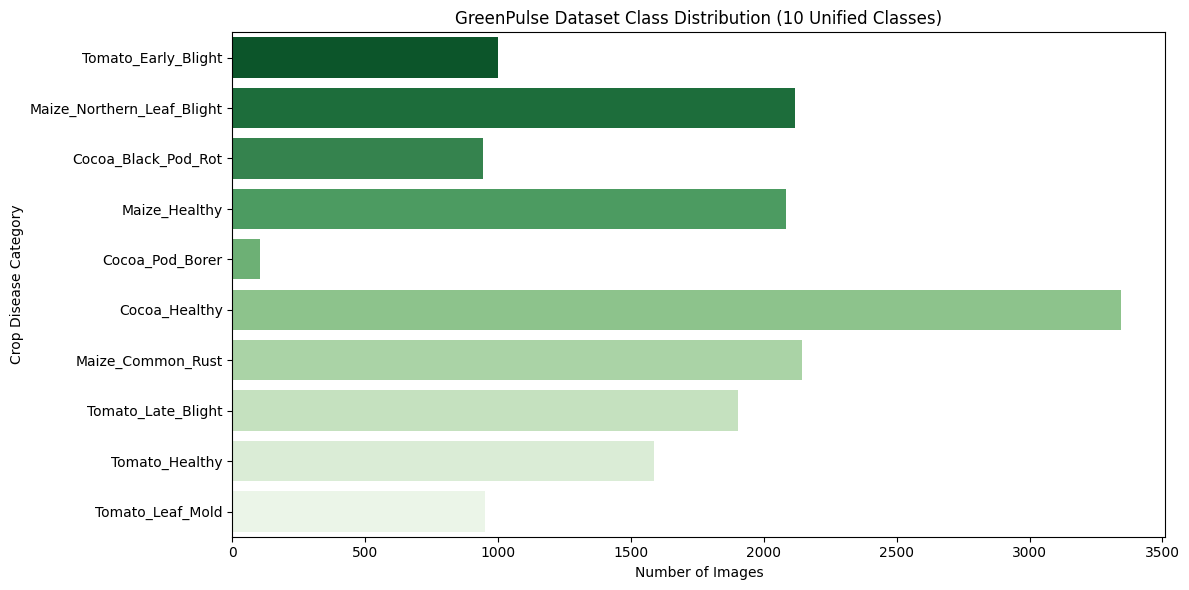

CUDA available: True
GPU: Tesla T4
True
Using device: cuda
GPU: Tesla T4
Train: 11320
Validation: 2425
Test: 2427
Training images: 11320
Validation images: 2425
Test images: 2427
Training batches: 354
Validation batches: 76
Test batches: 76


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([32, 3, 224, 224])
torch.Size([32])
✅ Custom GreenPulse CNN initialized from scratch for 10 classes!
Epoch  1/10 | train loss 1.718 acc 0.704 | val loss 0.398 acc 0.828
Epoch  2/10 | train loss 0.531 acc 0.801 | val loss 0.329 acc 0.864
Epoch  3/10 | train loss 0.497 acc 0.815 | val loss 0.295 acc 0.881
Epoch  4/10 | train loss 0.453 acc 0.830 | val loss 0.292 acc 0.888
Epoch  5/10 | train loss 0.429 acc 0.842 | val loss 0.269 acc 0.892
Epoch  6/10 | train loss 0.405 acc 0.856 | val loss 0.278 acc 0.891
Epoch  7/10 | train loss 0.377 acc 0.865 | val loss 0.283 acc 0.903
Epoch  8/10 | train loss 0.361 acc 0.869 | val loss 0.286 acc 0.901
Epoch  9/10 | train loss 0.378 acc 0.868 | val loss 0.283 acc 0.912
Epoch 10/10 | train loss 0.353 acc 0.875 | val loss 0.250 acc 0.901
{'train_loss': [1.7184354662684584, 0.5307449594824558, 0.4971484522094996, 0.45284342588889726, 0.4293086918419747, 0.4054726284300059, 0.37700010060000333, 0.3608324843929429, 0.3779469970890153, 0.35270220

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!git clone https://github.com/KekeliIsHere/GreenPulse.git
%cd GreenPulse
# %run notebooks/00_data_exploration_and_cleaning.ipynb
%run notebooks/01_personal_model_training.ipynb

In [ ]:
#Import the libraries and tools needed for the analysis
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [3]:
class GreenPulseCustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(GreenPulseCustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(
            128 * 28 * 28,
            256
        )

        self.fc2 = nn.Linear(
            256,
            num_classes
        )

    def forward(self, x):

        x = self.pool(
            F.relu(
                self.bn1(
                    self.conv1(x)
                )
            )
        )

        x = self.pool(
            F.relu(
                self.bn2(
                    self.conv2(x)
                )
            )
        )

        x = self.pool(
            F.relu(
                self.bn3(
                    self.conv3(x)
                )
            )
        )

        x = torch.flatten(x, 1)

        x = self.dropout(
            F.relu(
                self.fc1(x)
            )
        )

        x = self.fc2(x)

        return x

In [4]:
class_names = [
    "Cocoa_Black_Pod_Rot",
    "Cocoa_Healthy",
    "Cocoa_Pod_Borer",
    "Maize_Common_Rust",
    "Maize_Healthy",
    "Maize_Northern_Leaf_Blight",
    "Tomato_Early_Blight",
    "Tomato_Healthy",
    "Tomato_Late_Blight",
    "Tomato_Leaf_Mold"
]

In [ ]:
#Retrieve pth file from zipfile
import zipfile

with zipfile.ZipFile(
    "models/custom_greenpulse_model.pth.zip",
    "r"
) as zip_ref:

    zip_ref.extractall("models")

print(os.listdir("models"))

['custom_greenpulse_model', 'custom_greenpulse_model.pth.zip', 'crop_disease_model.pth', 'custom_greenpulse_model.pth']


In [ ]:
#Train and Evaluate the model 
custom_model = GreenPulseCustomCNN(
    num_classes=10
).to(device)

checkpoint = torch.load(
    "models/custom_greenpulse_model.pth.zip",
    map_location=device
)

custom_model.load_state_dict(checkpoint)

custom_model.eval()

print("Custom GreenPulse model loaded successfully!")

Custom GreenPulse model loaded successfully!


In [7]:
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
import os

for root, dirs, files in os.walk("/content/GreenPulse"):
    for file in files:
        if file.endswith(".ipynb"):
            print(os.path.join(root, file))

/content/GreenPulse/GreenPulse/notebooks/personal_evaluation.ipynb
/content/GreenPulse/GreenPulse/notebooks/evaluation.ipynb
/content/GreenPulse/GreenPulse/notebooks/00_data_exploration_and_cleaning.ipynb
/content/GreenPulse/GreenPulse/notebooks/model_processing.ipynb
/content/GreenPulse/GreenPulse/notebooks/01_model_training.ipynb
/content/GreenPulse/GreenPulse/notebooks/01_personal_model_training.ipynb
/content/GreenPulse/notebooks/personal_evaluation.ipynb
/content/GreenPulse/notebooks/evaluation.ipynb
/content/GreenPulse/notebooks/00_data_exploration_and_cleaning.ipynb
/content/GreenPulse/notebooks/model_processing.ipynb
/content/GreenPulse/notebooks/01_model_training.ipynb
/content/GreenPulse/notebooks/01_personal_model_training.ipynb


In [9]:
from pathlib import Path

dataset_path = Path("/content/clean_crop_dataset")

print("Dataset exists:", dataset_path.exists())

if dataset_path.exists():
    print("Classes:", [x.name for x in dataset_path.iterdir() if x.is_dir()])

Dataset exists: True
Classes: ['Tomato_Early_Blight', 'Maize_Northern_Leaf_Blight', 'Cocoa_Black_Pod_Rot', 'Maize_Healthy', 'Cocoa_Pod_Borer', 'Cocoa_Healthy', 'Maize_Common_Rust', 'Tomato_Late_Blight', 'Tomato_Healthy', 'Tomato_Leaf_Mold']


In [10]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

full_dataset = ImageFolder(
    root=dataset_path,
    transform=test_transform
)

total_size = len(full_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(0)

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Total:", total_size)
print("Train:", len(train_ds))
print("Validation:", len(val_ds))
print("Test:", len(test_ds))

Total: 16172
Train: 11320
Validation: 2425
Test: 2427


In [11]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test images:", len(test_ds))
print("Test batches:", len(test_loader))

Test images: 2427
Test batches: 76


In [12]:
custom_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = custom_model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )
        all_labels.extend(
            labels.cpu().numpy()
        )

print("Evaluation complete.")
print("Predictions:", len(all_predictions))
print("Labels:", len(all_labels))

Evaluation complete.
Predictions: 2427
Labels: 2427


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 92.91%


The custom GreenPulse CNN achieved a test accuracy of 93.16% across 2,427 test images. The model demonstrated strong performance on most maize and tomato classes, with particularly high F1-scores for Maize Healthy (99.66%), Maize Common Rust (99.04%), Maize Northern Leaf Blight (97.95%), and Tomato Healthy (99.58%). However, performance was substantially weaker for Cocoa Pod Borer, which achieved 0% precision, recall, and F1-score, and Cocoa Black Pod Rot, which achieved 64.62% F1-score. The lower performance on these cocoa disease classes is likely associated with their relatively small representation in the test set, particularly Cocoa Pod Borer with only 15 samples.

In [15]:
from sklearn.metrics import classification_report

class_names = full_dataset.classes

report = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
)

print("===== GreenPulse Custom CNN Classification Report =====")
print(report)

===== GreenPulse Custom CNN Classification Report =====
                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.90      0.50      0.65       125
             Cocoa_Healthy       0.87      0.99      0.93       535
           Cocoa_Pod_Borer       0.00      0.00      0.00        15
         Maize_Common_Rust       0.99      0.99      0.99       315
             Maize_Healthy       0.99      1.00      1.00       296
Maize_Northern_Leaf_Blight       0.96      0.99      0.97       338
       Tomato_Early_Blight       0.88      0.74      0.80       131
            Tomato_Healthy       1.00      1.00      1.00       236
        Tomato_Late_Blight       0.87      0.88      0.87       291
          Tomato_Leaf_Mold       0.90      0.91      0.90       145

                  accuracy                           0.93      2427
                 macro avg       0.84      0.80      0.81      2427
              weighted avg       0.92      0.93      0.92 

<Figure size 1000x800 with 0 Axes>

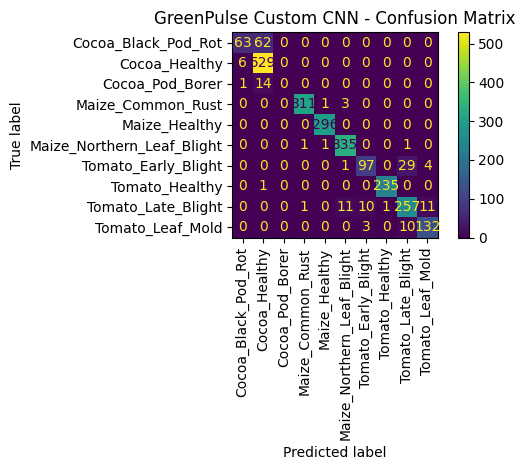

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(10))
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("GreenPulse Custom CNN - Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
import numpy as np

# Correct predictions for each class
correct = np.diag(cm)

# Total actual samples for each class
total = cm.sum(axis=1)

# Per-class accuracy
class_accuracy = correct / total

print("Per-Class Accuracy:\n")

for name, acc in zip(class_names, class_accuracy):
    print(f"{name:30s}: {acc * 100:.2f}%")

Per-Class Accuracy:

Cocoa_Black_Pod_Rot           : 50.40%
Cocoa_Healthy                 : 98.88%
Cocoa_Pod_Borer               : 0.00%
Maize_Common_Rust             : 98.73%
Maize_Healthy                 : 100.00%
Maize_Northern_Leaf_Blight    : 99.11%
Tomato_Early_Blight           : 74.05%
Tomato_Healthy                : 99.58%
Tomato_Late_Blight            : 88.32%
Tomato_Leaf_Mold              : 91.03%


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision_macro = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("===== GreenPulse Custom CNN Evaluation =====")
print(f"Accuracy:           {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Macro Precision:    {precision_macro:.4f}")
print(f"Macro Recall:       {recall_macro:.4f}")
print(f"Macro F1:           {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1:        {f1_weighted:.4f}")

===== GreenPulse Custom CNN Evaluation =====
Accuracy:           0.9291 (92.91%)
Macro Precision:    0.8358
Macro Recall:       0.8001
Macro F1:           0.8113
Weighted Precision: 0.9240
Weighted Recall:    0.9291
Weighted F1:        0.9225


In [19]:
evaluation_results = {
    "test_accuracy": accuracy,
    "macro_precision": precision_macro,
    "macro_recall": recall_macro,
    "macro_f1": f1_macro,
    "weighted_precision": precision_weighted,
    "weighted_recall": recall_weighted,
    "weighted_f1": f1_weighted
}

print("===== Final Evaluation Results =====")

for metric, value in evaluation_results.items():
    print(f"{metric}: {value:.4f}")

===== Final Evaluation Results =====
test_accuracy: 0.9291
macro_precision: 0.8358
macro_recall: 0.8001
macro_f1: 0.8113
weighted_precision: 0.9240
weighted_recall: 0.9291
weighted_f1: 0.9225


In [20]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    labels=list(range(len(class_names))),
    zero_division=0
)

print("===== Lowest Performing Classes =====")

for i in sorted(range(len(class_names)), key=lambda x: f1[x]):
    print(
        f"{class_names[i]:35s} "
        f"F1: {f1[i]:.2%} | "
        f"Precision: {precision[i]:.2%} | "
        f"Recall: {recall[i]:.2%} | "
        f"Support: {support[i]}"
    )

===== Lowest Performing Classes =====
Cocoa_Pod_Borer                     F1: 0.00% | Precision: 0.00% | Recall: 0.00% | Support: 15
Cocoa_Black_Pod_Rot                 F1: 64.62% | Precision: 90.00% | Recall: 50.40% | Support: 125
Tomato_Early_Blight                 F1: 80.50% | Precision: 88.18% | Recall: 74.05% | Support: 131
Tomato_Late_Blight                  F1: 87.41% | Precision: 86.53% | Recall: 88.32% | Support: 291
Tomato_Leaf_Mold                    F1: 90.41% | Precision: 89.80% | Recall: 91.03% | Support: 145
Cocoa_Healthy                       F1: 92.73% | Precision: 87.29% | Recall: 98.88% | Support: 535
Maize_Northern_Leaf_Blight          F1: 97.38% | Precision: 95.71% | Recall: 99.11% | Support: 338
Maize_Common_Rust                   F1: 99.04% | Precision: 99.36% | Recall: 98.73% | Support: 315
Tomato_Healthy                      F1: 99.58% | Precision: 99.58% | Recall: 99.58% | Support: 236
Maize_Healthy                       F1: 99.66% | Precision: 99.33% | Recall